# **1. PROJECT UNDERSTANDING**

> The purpose of this datasets is to determine how many factors,including gender, age, education level, institute type, IT student, location, load-shedding, financial condition, internet type, network type, class duration, self LMS, device, and adaptivity level, affect the performance of students enrolled in online courses.

The data consists of 14 columns and 1205 rows.

Column Meaning;

1.   Gender (Female or Male)
2.   Age (1-5,6-10,11-15,16-20,21-25,  26-30)
3.   Education Level (Student, College, University)
4.   Institution Type (Goverment or Non-Goverment)
5.   IT Student (Yes or No)
6.   Location - Is student in town? (Yes or No)
7.   Load-shedding - Temporary reduction of electric power in a particular area (Low or High)
8.   Financial Condition (Mid, Poor, Rich)
9.   Internet Type (Mobile Data or Wifi)
10.  Network Type (2G, 3G, or 4G)
11.  Class Duration (1-3,3-6,0)
12.  Self LMS - Self Learning Management System (Yes or No)
13.  Device - Device used in online learning (Mobile, Computer, Tab)
14.  Adaptivity Level (Low,Moderate, High)


# **2. DATA MINING**

In [3]:
# Import necessary libraries & modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn import datasets
%matplotlib inline

from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn import tree
from sklearn import metrics

In [4]:
# Reading a CSV file into a pandas DataFrame.

data = pd.read_csv('virtualeducationadaptability.csv')

In [5]:
# Displaying the first 20 rows of the DataFrame.

data.head(20)

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,Boy,21-25,University,Non Government,No,Yes,Low,Mid,Wifi,4G,3-6,No,Tab,Moderate
1,Girl,21-25,University,Non Government,No,Yes,High,Mid,Mobile Data,4G,1-3,Yes,Mobile,Moderate
2,Girl,16-20,College,Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Moderate
3,Girl,11-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
4,Girl,16-20,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,0,No,Mobile,Low
5,Boy,11-15,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,1-3,No,Mobile,Low
6,Boy,11-15,School,Non Government,No,Yes,Low,Mid,Wifi,4G,0,No,Mobile,Low
7,Boy,11-15,School,Non Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Moderate
8,Boy,16-20,College,Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Low
9,Boy,11-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,3G,1-3,No,Mobile,Moderate


In [6]:
# Displaying the last 10 rows of the DataFrame.

data.tail(10)

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
1195,Boy,21-25,University,Non Government,Yes,Yes,High,Poor,Wifi,4G,1-3,Yes,Computer,High
1196,Boy,16-20,College,Government,No,No,High,Mid,Mobile Data,3G,1-3,No,Mobile,Low
1197,Boy,21-25,University,Non Government,Yes,Yes,Low,Mid,Mobile Data,4G,3-6,No,Computer,Moderate
1198,Boy,16-20,College,Government,Yes,No,Low,Mid,Mobile Data,4G,0,No,Mobile,Low
1199,Boy,21-25,University,Non Government,Yes,Yes,Low,Mid,Wifi,4G,3-6,No,Computer,Low
1200,Girl,16-20,College,Non Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Low
1201,Girl,16-20,College,Non Government,No,No,High,Mid,Wifi,4G,3-6,No,Mobile,Moderate
1202,Boy,11-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,3G,1-3,No,Mobile,Moderate
1203,Girl,16-20,College,Non Government,No,No,Low,Mid,Wifi,4G,1-3,No,Mobile,Low
1204,Girl,11-15,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,1-3,No,Mobile,Moderate


In [7]:
# Retrieve the shape of the array (1205 rows and 14 columns)

data.shape

(1205, 14)

In [8]:
# Check for missing values in the DataFrame to decide whether or not to throw column or row.

data.isna().sum()

,0
Gender,0
Age,0
Education Level,0
Institution Type,0
IT Student,0
Location,0
Load-shedding,0
Financial Condition,0
Internet Type,0
Network Type,0


In [9]:
# Used to obtain a concise summary of a Pandas DataFrame

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Gender               1205 non-null   object
 1   Age                  1205 non-null   object
 2   Education Level      1205 non-null   object
 3   Institution Type     1205 non-null   object
 4   IT Student           1205 non-null   object
 5   Location             1205 non-null   object
 6   Load-shedding        1205 non-null   object
 7   Financial Condition  1205 non-null   object
 8   Internet Type        1205 non-null   object
 9   Network Type         1205 non-null   object
 10  Class Duration       1205 non-null   object
 11  Self Lms             1205 non-null   object
 12  Device               1205 non-null   object
 13  Adaptivity Level     1205 non-null   object
dtypes: object(14)
memory usage: 131.9+ KB


In [10]:
# To generate descriptive statistics of the columns in the DataFrame.

data.describe()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
count,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205
unique,2,6,3,2,2,2,2,3,2,3,3,2,3,3
top,Boy,21-25,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
freq,663,374,530,823,901,935,1004,878,695,775,840,995,1013,625


#  **3. DATA CLEANING**

In [11]:
# Check all the data types of the columns

data_types = data.dtypes
print(data_types)

Gender                 object
Age                    object
Education Level        object
Institution Type       object
IT Student             object
Location               object
Load-shedding          object
Financial Condition    object
Internet Type          object
Network Type           object
Class Duration         object
Self Lms               object
Device                 object
Adaptivity Level       object
dtype: object


In [12]:
# Remove spaces in columns name and change some with underscores.

data.columns = data.columns.str.replace(' ','_')
data.columns = data.columns.str.replace('-','_')

In [13]:
# To generate the new descriptive statistics of the columns in the DataFrame.

data.describe()

,Gender,Age,Education_Level,Institution_Type,IT_Student,Location,Load_shedding,Financial_Condition,Internet_Type,Network_Type,Class_Duration,Self_Lms,Device,Adaptivity_Level
count,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205
unique,2,6,3,2,2,2,2,3,2,3,3,2,3,3
top,Boy,21-25,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
freq,663,374,530,823,901,935,1004,878,695,775,840,995,1013,625


- We remove the ('-') with underscores ('_') to easily access the columns name while analyzing them.

In [14]:
# Making name changes in the data to optimise it more efficiently

data.rename(columns = {'Age': 'Age_Range'}, inplace = True)

data.replace("Boy","Male", inplace=True)
data.replace("Girl","Female", inplace=True)
data.replace("Poor","Lower Class", inplace=True)
data.replace("Mid","Middle Class", inplace=True)
data.replace("Rich","Upper Class", inplace=True)

In [15]:
# Displaying the first 6 rows of the DataFrame.

data.head(6)

,Gender,Age_Range,Education_Level,Institution_Type,IT_Student,Location,Load_shedding,Financial_Condition,Internet_Type,Network_Type,Class_Duration,Self_Lms,Device,Adaptivity_Level
0,Male,21-25,University,Non Government,No,Yes,Low,Middle Class,Wifi,4G,3-6,No,Tab,Moderate
1,Female,21-25,University,Non Government,No,Yes,High,Middle Class,Mobile Data,4G,1-3,Yes,Mobile,Moderate
2,Female,16-20,College,Government,No,Yes,Low,Middle Class,Wifi,4G,1-3,No,Mobile,Moderate
3,Female,11-15,School,Non Government,No,Yes,Low,Middle Class,Mobile Data,4G,1-3,No,Mobile,Moderate
4,Female,16-20,School,Non Government,No,Yes,Low,Lower Class,Mobile Data,3G,0,No,Mobile,Low
5,Male,11-15,School,Non Government,No,Yes,Low,Lower Class,Mobile Data,3G,1-3,No,Mobile,Low


- We have change the data for Gender column has change from "Boy" and "Girl" to "Male" and "Female", and Financial Condition column from "Poor", "Mid", and "Rich" to "Lower, Middle, and Upper Class" to make our data more suitable for analysis.

In [16]:
# A method that returns the number of unique values for each column in a DataFrame.

data.nunique()

,0
Gender,2
Age_Range,6
Education_Level,3
Institution_Type,2
IT_Student,2
Location,2
Load_shedding,2
Financial_Condition,3
Internet_Type,2
Network_Type,3


# **3. DATA EXPLORATION**

In [17]:
# Identifying and categorizing numerical and categorical features in a Pandas DataFrame.

numeric_features = data.select_dtypes(include=['int64', 'float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns

print(f'We have {len(numeric_features)} numerical features: {list(numeric_features)}')
print(f'We have {len(categorical_features)} categorical features: {list(categorical_features)}')

We have 0 numerical features: []
We have 14 categorical features: ['Gender', 'Age_Range', 'Education_Level', 'Institution_Type', 'IT_Student', 'Location', 'Load_shedding', 'Financial_Condition', 'Internet_Type', 'Network_Type', 'Class_Duration', 'Self_Lms', 'Device', 'Adaptivity_Level']


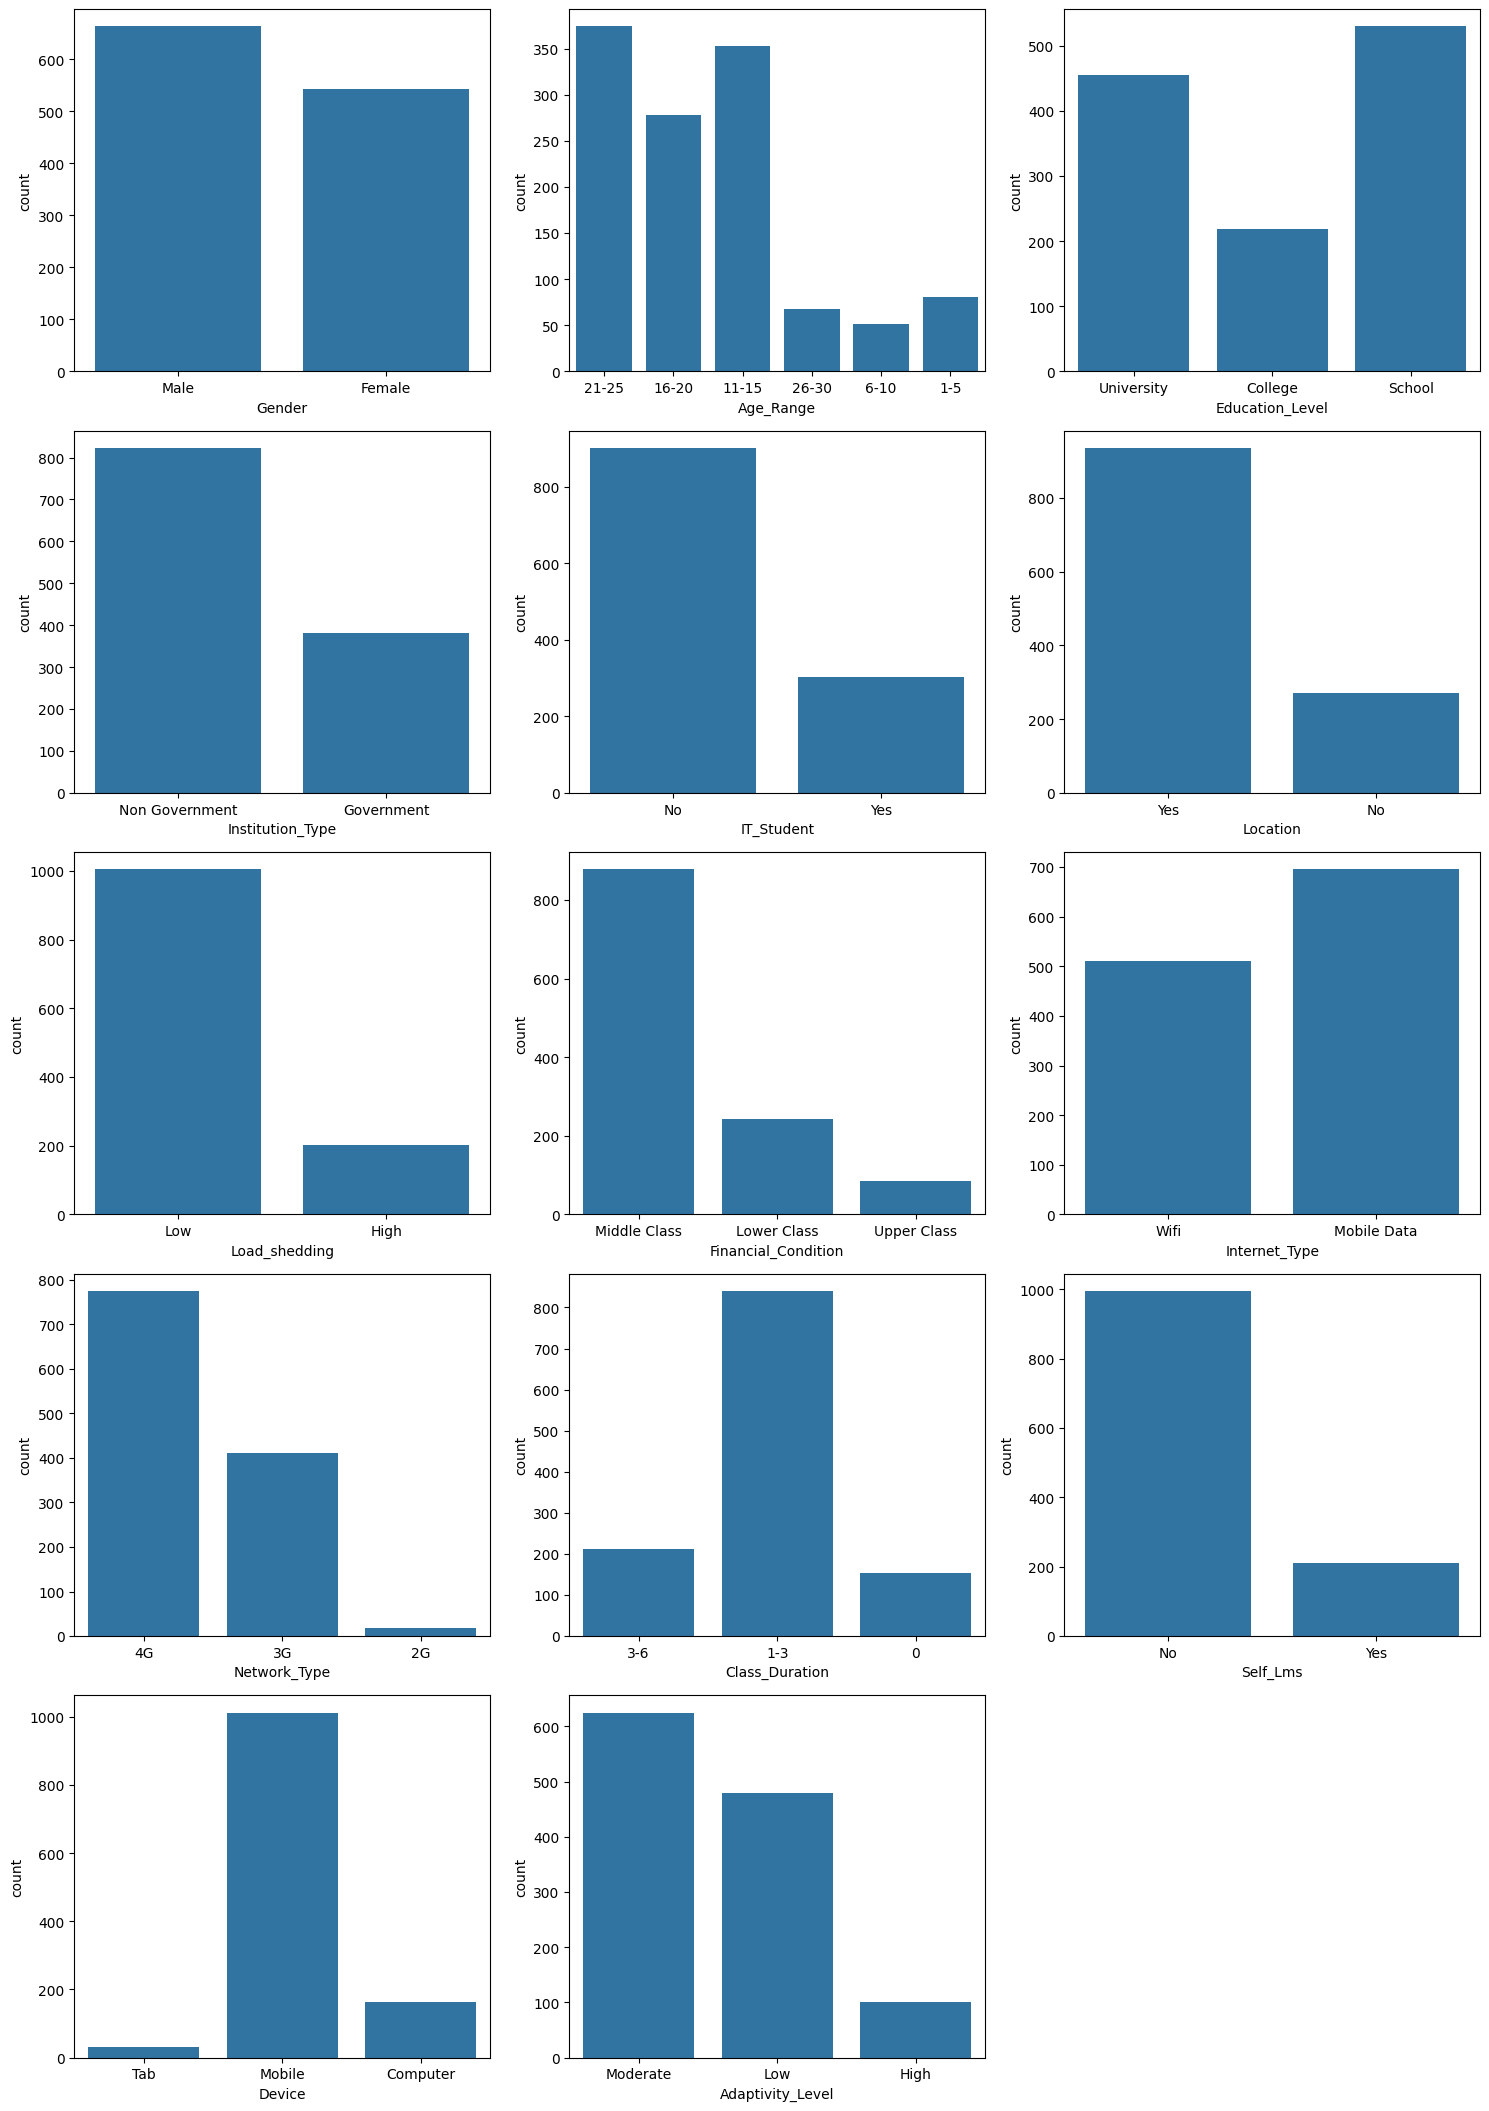

In [18]:
# Create a set of count plots for each columns in the dataset.
i = 1
plt.figure(figsize = (15,25))
for feature in  data :
    plt.subplot(6,3,i)
    sns.countplot(x = feature , data = data)
    i +=1

plt.tight_layout()
plt.show()

In [19]:
# To obtain the values in the 'Adaptivity_Level' column of the Pandas DataFrame.

data['Adaptivity_Level'].value_counts()

,count
Adaptivity_Level,
Moderate,625
Low,480
High,100


In [20]:
# To obtain the values in the 'Gender' column of the Pandas DataFrame.

data['Gender'].value_counts()

,count
Gender,
Male,663
Female,542


In [21]:
# Create a loop that iterates over each column of the unique values in the DataFrame.

for i in data.columns:
    print(i, ":", data[i].unique().tolist())

Gender : ['Male', 'Female']
Age_Range : ['21-25', '16-20', '11-15', '26-30', '6-10', '1-5']
Education_Level : ['University', 'College', 'School']
Institution_Type : ['Non Government', 'Government']
IT_Student : ['No', 'Yes']
Location : ['Yes', 'No']
Load_shedding : ['Low', 'High']
Financial_Condition : ['Middle Class', 'Lower Class', 'Upper Class']
Internet_Type : ['Wifi', 'Mobile Data']
Network_Type : ['4G', '3G', '2G']
Class_Duration : ['3-6', '1-3', '0']
Self_Lms : ['No', 'Yes']
Device : ['Tab', 'Mobile', 'Computer']
Adaptivity_Level : ['Moderate', 'Low', 'High']


In [22]:
# To obtain the values in the 'Financial_Condition' column of the Pandas DataFrame.

data['Financial_Condition'].value_counts()

,count
Financial_Condition,
Middle Class,878
Lower Class,242
Upper Class,85


In [23]:
# To obtain the values in the 'Age_Range' column of the Pandas DataFrame.

data['Age_Range'].value_counts()

,count
Age_Range,
21-25,374
11-15,353
16-20,278
1-5,81
26-30,68
6-10,51


In [24]:
# To obtain the values in the 'Education_Level' column of the Pandas DataFrame.

data['Education_Level'].value_counts()

,count
Education_Level,
School,530
University,456
College,219


In [25]:
# To obtain the values in the 'Self_Lms' column of the Pandas DataFrame.

data['Self_Lms'].value_counts()

,count
Self_Lms,
No,995
Yes,210


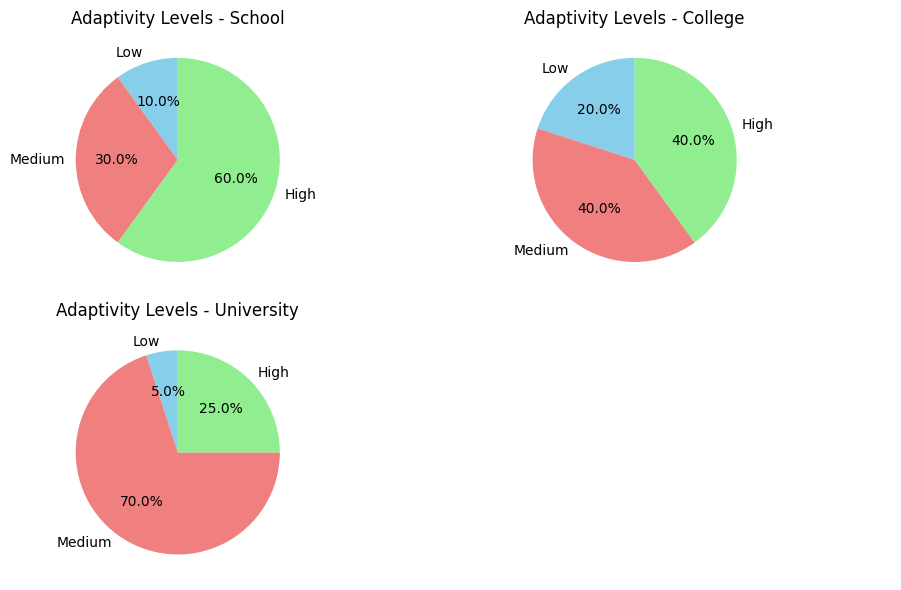

In [26]:
# Creating a set of pie charts to visualize the distribution of adaptivity levels across different education levels.

education_levels = ['School', 'College', 'University']
adaptivity_levels = ['Low', 'Medium', 'High']
percentages = [[10, 30, 60], [20, 40, 40], [5, 70, 25], [15, 20, 65]]

# Plotting a pie chart for each education level
fig, ax = plt.subplots(figsize=(10, 6), nrows=2, ncols=2)

# Turn off the axis for the entire set of subplots
plt.axis('off')

for i, education_level in enumerate(education_levels):
    ax[i // 2, i % 2].pie(
        percentages[i],
        labels=adaptivity_levels,
        autopct='%1.1f%%',
        startangle=90,
        colors=['skyblue', 'lightcoral', 'lightgreen']
    )
    ax[i // 2, i % 2].set_title(f'Adaptivity Levels - {education_level}')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1079/2631755697.py:11: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(data=data, x=col, hue="Device", palette=sns.color_palette("Spectral"), order=class_order)


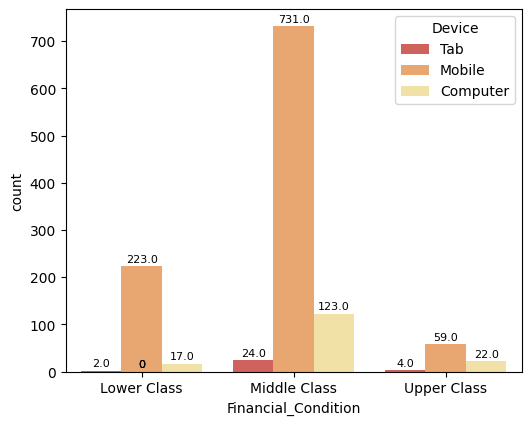

In [27]:
# Creating a set of count plots for the 'Financial Condition', with each subplot differentiated by the 'Device'.

class_order = ['Lower Class', 'Middle Class', 'Upper Class']

UserProfile = ['Financial_Condition']
plt.figure(figsize=(20, 16))

for i, col in enumerate(UserProfile, 1):
    ax = plt.subplot(3, 3, i)

    sns.countplot(data=data, x=col, hue="Device", palette=sns.color_palette("Spectral"), order=class_order)

    # Add counts on top of each bar
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),textcoords='offset points')

plt.show()

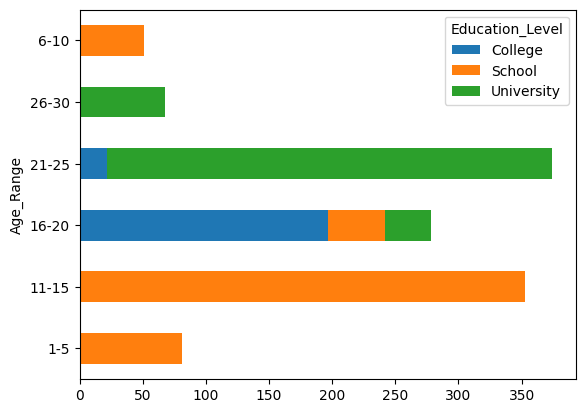

In [28]:
# Create a cross table of 'Age Range' and 'Education Level'.

pd.crosstab(data['Age_Range'], data['Education_Level']).plot(kind='barh', stacked=True)
plt.show()

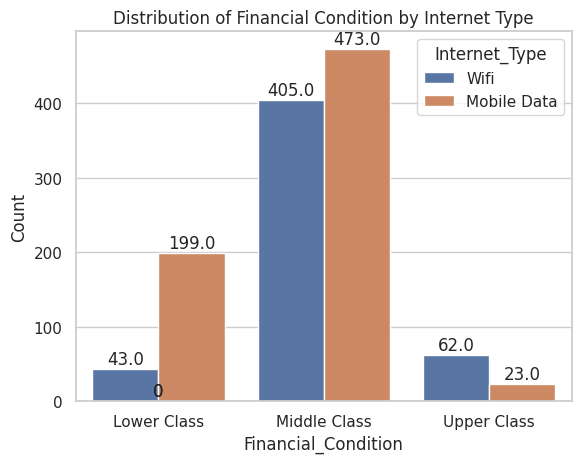

In [29]:
# Generates a countplot to visualize the distribution of financial conditions based on different internet types.

sns.set(style="whitegrid")
financial_order = ['Lower Class', 'Middle Class', 'Upper Class']
ax = sns.countplot(x='Financial_Condition', hue='Internet_Type', data=data, order=financial_order)

# Add count labels to each bar.
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 7), textcoords='offset points')

plt.xlabel('Financial_Condition')
plt.ylabel('Count')
plt.title('Distribution of Financial Condition by Internet Type')

plt.show()

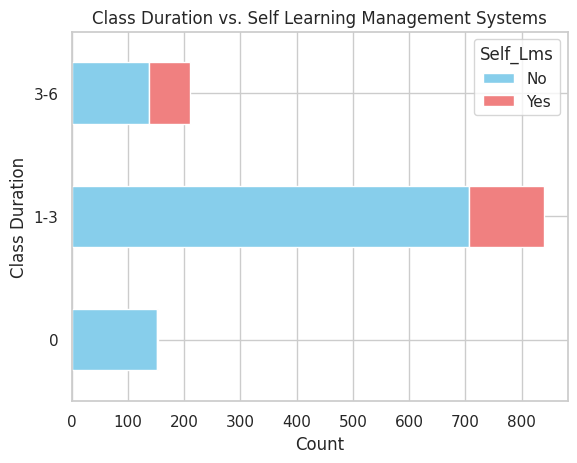

In [30]:
# Create a cross-table of 'Class Duration' and 'Self Lms'

class_duration_self_lms_cross = pd.crosstab(data['Class_Duration'], data['Self_Lms'])

# Define custom colors for each category

colors = ['skyblue', 'lightcoral', 'lightgreen']

class_duration_self_lms_cross.plot(kind='barh', stacked=True, color=colors)
plt.title('Class Duration vs. Self Learning Management Systems')
plt.xlabel('Count')
plt.ylabel('Class Duration')
plt.show()

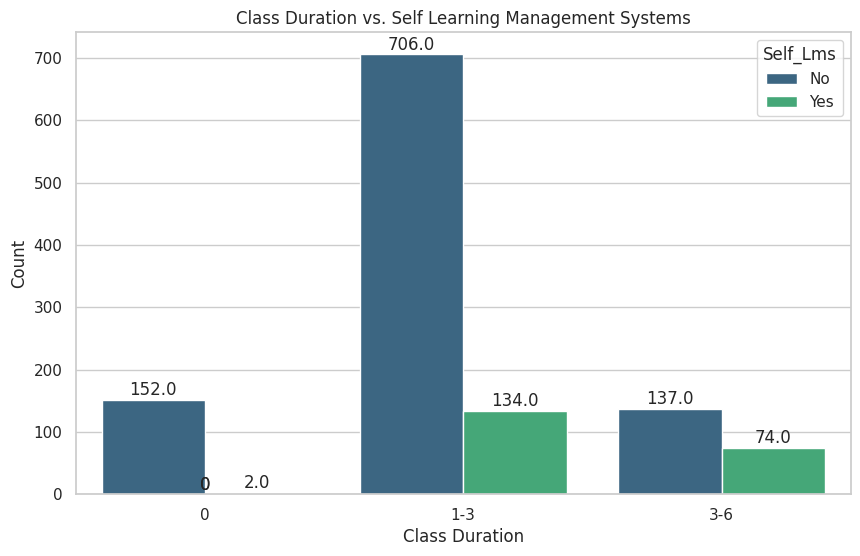

In [31]:
# Code generates a grouped bar chart to compare the distribution of 'Self_Lms' within different categories of 'Class_Duration'

sns.set(style="whitegrid")
class_duration = ['0', '1-3', '3-6']

plt.figure(figsize=(10, 6))
sns.countplot(x='Class_Duration', hue='Self_Lms', data=data, palette='viridis', order=class_duration)

# Add counts on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),ha='center', va='center', xytext=(0, 7), textcoords='offset points')

plt.xlabel('Class Duration')
plt.ylabel('Count')
plt.title('Class Duration vs. Self Learning Management Systems')
plt.show()

/tmp/ipykernel_1079/892684950.py:8: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  ax = sns.countplot(data=data, x=col, hue="Adaptivity_Level", palette=sns.color_palette("Set1"))
/tmp/ipykernel_1079/892684950.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
/tmp/ipykernel_1079/892684950.py:8: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  ax = sns.countplot(data=data, x=col, hue="Adaptivity_Level", palette=sns.color_palette("Set1"))
/tmp/ipykernel_1079/892684950.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
/tmp/ipykernel_1079/892684950.py:8: UserWarn

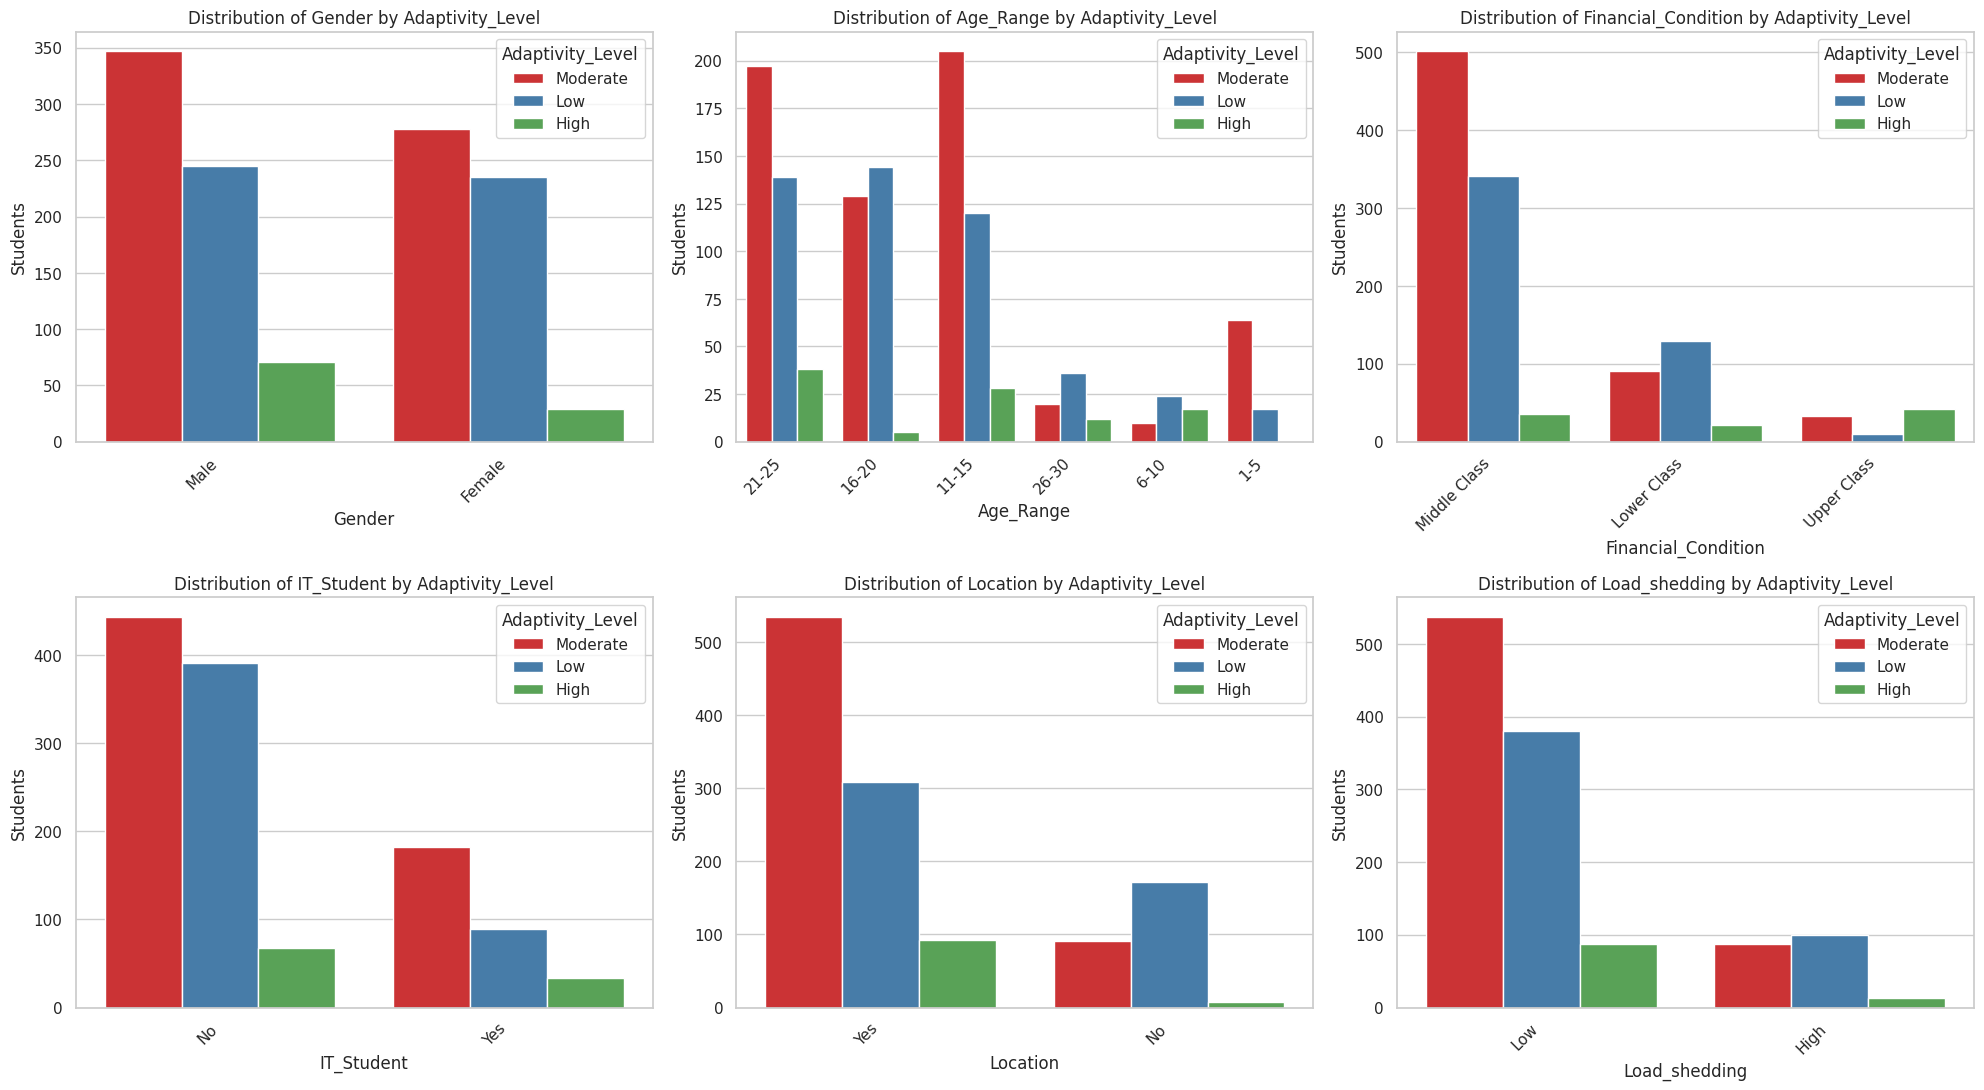

In [32]:
# Generates a set of subplots to visualize the distribution of various columns ('Gender', 'Age Range', 'Financial Condition', 'IT Student', 'Location', 'Load shedding') with 'Adaptivity Level'.

plt.figure(figsize=(20, 16))
UserProfile = ['Gender', 'Age_Range', 'Financial_Condition', 'IT_Student', 'Location', 'Load_shedding']

for i, col in enumerate(UserProfile, 1):
    plt.subplot(3, 3, i)
    ax = sns.countplot(data=data, x=col, hue="Adaptivity_Level", palette=sns.color_palette("Set1"))

    ax.set_xlabel(col)
    ax.set_ylabel('Students')
    ax.set_title(f'Distribution of {col} by Adaptivity_Level')

    # Optionally rotate x-axis labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

plt.tight_layout()
plt.show()

# **5. FEATURE ENGINEERING**

In [33]:
# Encode the categorical data into numerical so that the machine learning can read them.

spiral_encoding = {

    'Gender' : {
        'Male': 1 ,
        'Female':  0
    },

    'Age_Range' : {
        '26-30' : 5,
        '21-25' : 4,
        '16-20' : 3,
        '11-15' : 2,
        '6-10'  : 1,
        '1-5'   : 0
    },

    'Education_Level' : {
        'University' : 2,
        'College'    : 1,
        'School'     : 0
    },

    'Institution_Type' : {
        'Government'    : 1,
        'Non Government': 0,
    },

    'IT_Student' : {
        'No'  : 0,
        'Yes' : 1
    },

    'Location' : {
        'No'  : 0,
        'Yes' : 1
    },

    'Load_shedding' : {
        'Low'  : 0,
        'High' : 1
    },

    'Financial_Condition' : {
        'Lower Class' : 0,
        'Middle Class'  : 1,
        'Upper Class' : 2
    },

    'Internet_Type'   :{
        'Wifi':        1,
        'Mobile Data': 0
    },

    'Network_Type' : {
        '4G' : 2,
        '3G' : 1,
        '2G' : 0
    },

    'Class_Duration' : {
        '3-6' : 2,
        '1-3' : 1,
        '0'   : 0,
    },

    'Self_Lms' : {
        'No'  : 0,
        'Yes' : 1
    },

    'Device'  : {
        'Tab': 1,
        'Mobile' : 0,
        'Computer': 2
    },

    'Adaptivity_Level' : {
        'Low'      : 0,
        'Moderate' : 1,
        'High'     : 2
    }
}

# Create a loops that replaces the original values with encoded values.

for column in data:
    if column in spiral_encoding.keys():
        try:
            data[column] = data[column].apply( lambda x : spiral_encoding[column][x] )
        except:
            print(f"Skipped {column}")

In [34]:
# Retrieve the summary of the DataFrame, including information about the data types of each column.

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Gender               1205 non-null   int64
 1   Age_Range            1205 non-null   int64
 2   Education_Level      1205 non-null   int64
 3   Institution_Type     1205 non-null   int64
 4   IT_Student           1205 non-null   int64
 5   Location             1205 non-null   int64
 6   Load_shedding        1205 non-null   int64
 7   Financial_Condition  1205 non-null   int64
 8   Internet_Type        1205 non-null   int64
 9   Network_Type         1205 non-null   int64
 10  Class_Duration       1205 non-null   int64
 11  Self_Lms             1205 non-null   int64
 12  Device               1205 non-null   int64
 13  Adaptivity_Level     1205 non-null   int64
dtypes: int64(14)
memory usage: 131.9 KB


In [35]:
# Display the first 10 rows of the DataFrame.

data.head(10)

,Gender,Age_Range,Education_Level,Institution_Type,IT_Student,Location,Load_shedding,Financial_Condition,Internet_Type,Network_Type,Class_Duration,Self_Lms,Device,Adaptivity_Level
0,1,4,2,0,0,1,0,1,1,2,2,0,1,1
1,0,4,2,0,0,1,1,1,0,2,1,1,0,1
2,0,3,1,1,0,1,0,1,1,2,1,0,0,1
3,0,2,0,0,0,1,0,1,0,2,1,0,0,1
4,0,3,0,0,0,1,0,0,0,1,0,0,0,0
5,1,2,0,0,0,1,0,0,0,1,1,0,0,0
6,1,2,0,0,0,1,0,1,1,2,0,0,0,0
7,1,2,0,0,0,1,0,1,1,2,1,0,0,1
8,1,3,1,1,0,1,0,1,1,2,1,0,0,0
9,1,2,0,0,0,1,0,1,0,1,1,0,0,1


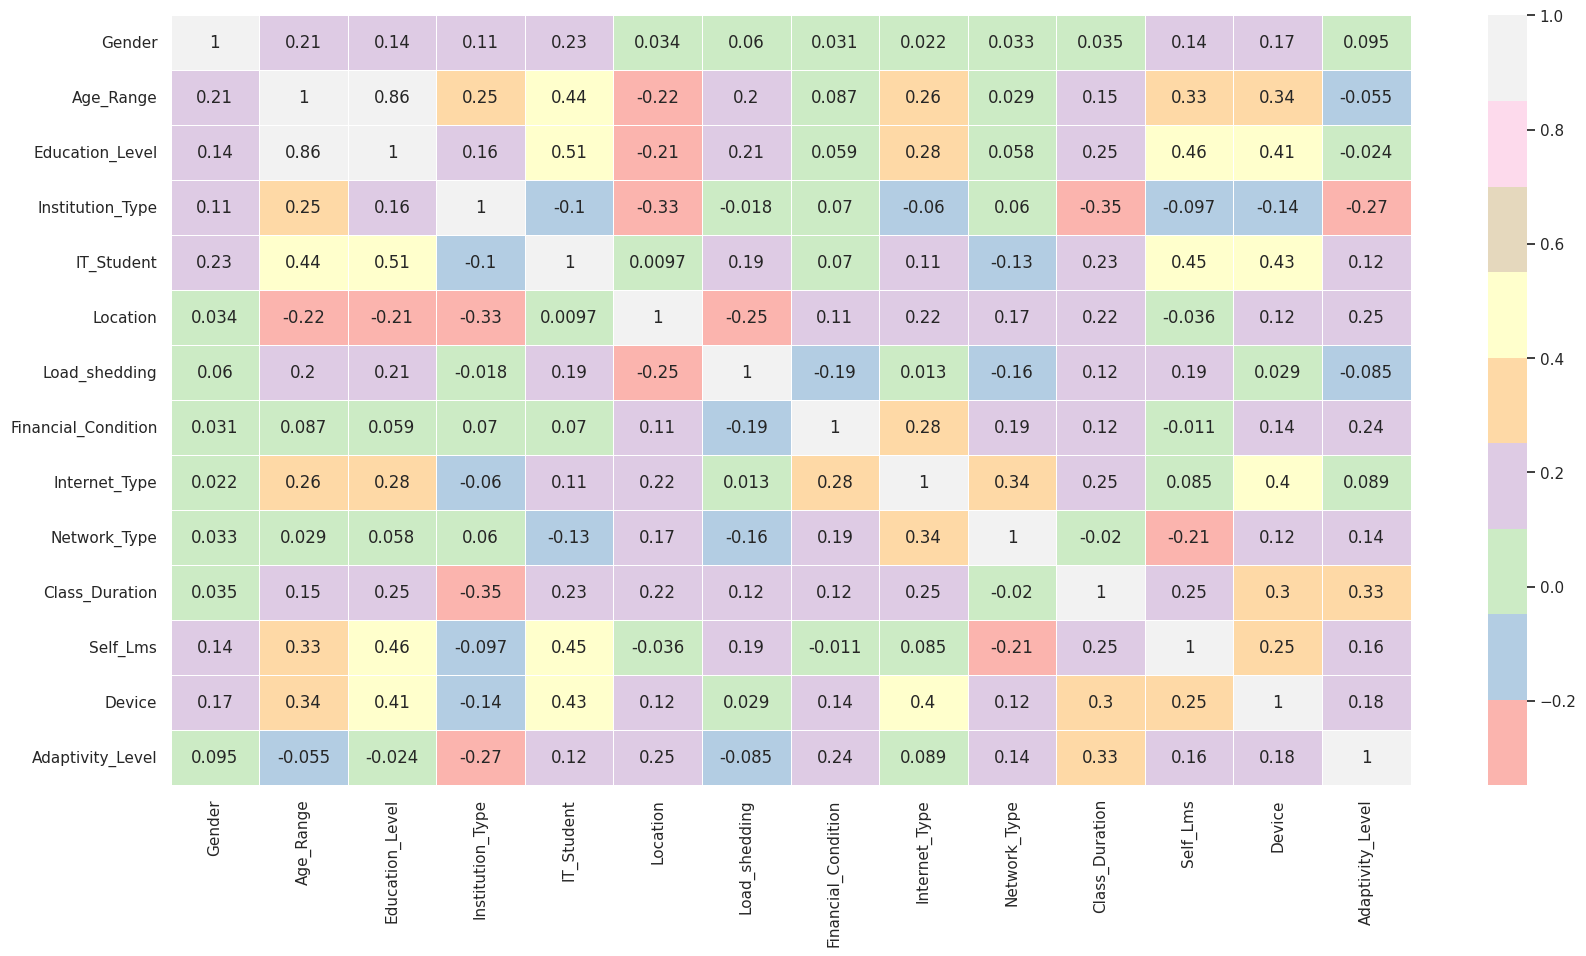

In [36]:
# Create a heatmap to see which variable has the highest correlation.

correlations = data.corr()

plt.figure(figsize=(20, 10))  # Adjust the width and height as needed
sns.heatmap(correlations, linewidths=0.5, cmap="Pastel1", linecolor='white', annot=True)
plt.show()

# **6. PREDICTIVE MODELLING**

**GUASSIAN PROCESS CLASSIFIER MODEL**

In [37]:
#Split the data into features (x) and target class (y).

x = data.drop(columns = ['Adaptivity_Level'], axis=1)
y = data['Adaptivity_Level']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [38]:
# Standardize the data

scaler = StandardScaler()
x_train_stand = scaler.fit_transform(x_train)
x_test_stand = scaler.transform(x_test)

In [39]:
# Initialize the Gaussian Process Classifier
kernel = 1.0 * RBF(length_scale=1.0)
gp_classifier = GaussianProcessClassifier(kernel=kernel, random_state=0)

# Fit the classifier
gp_classifier.fit(x_train_stand, y_train)

# Predict
y_pred = gp_classifier.predict(x_test_stand)

# Calculate training accuracy
accuracy_gp = accuracy_score(y_train, gp_classifier.predict(x_train_stand))
print(f"Training Accuracy: {accuracy_gp:.4f}")

# Test Accuracy
test_accuracy_gp = accuracy_score(y_test, gp_classifier.predict(x_test_stand))
print(f"Test Accuracy: {test_accuracy_gp:.4f}")

# Print classification report
print(classification_report(y_test, y_pred))

Training Accuracy: 0.8826
Test Accuracy: 0.8204
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       154
           1       0.81      0.93      0.87       169
           2       0.00      0.00      0.00        39

    accuracy                           0.82       362
   macro avg       0.55      0.61      0.58       362
weighted avg       0.73      0.82      0.77       362



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


*   
*    
*  
*  
*    
*    







 **LOGISTIC REGRESSION MODEL**

In [40]:
#Split the data into features (x) and target class (y).

x = data.drop(columns = ['Adaptivity_Level'], axis=1)
y = data['Adaptivity_Level']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [41]:
lr = LogisticRegression(max_iter=1000)

# Train the model
lr.fit(x_train, y_train)

# Predict on the test set
y_pred = lr.predict(x_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred)

In [42]:
print("Train Accuracy :", accuracy_score(y_train, lr.predict(x_train)))
print("Test Accuracy:", accuracy_lr)

# Generate and print the classification report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

Train Accuracy : 0.7034400948991696
Test Accuracy: 0.6657458563535912

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.60      0.68       154
           1       0.61      0.86      0.71       169
           2       1.00      0.08      0.14        39

    accuracy                           0.67       362
   macro avg       0.79      0.51      0.51       362
weighted avg       0.72      0.67      0.64       362



*   
*    
*  
*  
*    
*    







 **DECISION TREE MODEL**

In [43]:
# Create a DecisionTreeClassifier with maximum depth set to 2

clf = DecisionTreeClassifier(max_depth=2)

In [44]:
# Train the model on training data (x_train, y_train).

clf.fit(x_train, y_train)

# We make cross validation to evaluate its performance on multiple subsets of the training data.

cv_score = cross_val_score(clf, x_train, y_train, cv=10)
print(cv_score)

[0.72941176 0.67058824 0.64705882 0.60714286 0.64285714 0.60714286
 0.61904762 0.5952381  0.64285714 0.58333333]


In [45]:
# Retrieve the unique values present in the y_train array
y_train.unique()

array([1, 0, 2])

In [46]:
# Retrieve the details in the x_train features.

x_train

,Gender,Age_Range,Education_Level,Institution_Type,IT_Student,Location,Load_shedding,Financial_Condition,Internet_Type,Network_Type,Class_Duration,Self_Lms,Device
354,1,2,0,0,0,1,0,1,0,2,1,0,0
1053,1,2,0,0,0,1,1,0,1,2,0,0,0
413,0,3,1,0,0,0,0,1,1,2,1,0,0
256,1,3,1,1,0,1,1,1,1,2,1,0,0
291,1,2,0,0,0,1,0,1,1,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,0,3,1,0,0,1,1,1,1,2,2,0,0
1095,0,4,2,0,1,1,0,2,1,2,2,0,2
1130,1,2,0,0,0,1,1,0,1,2,1,0,0
860,1,4,2,0,0,1,0,1,0,2,0,0,0


In [47]:
# Extracting column names from the DataFrame and defining class names for fn and cn

fn=x.columns.values.tolist()
cn = ['Low', 'Moderate', 'High']

In [48]:
# 'fn' now contains a list of column names extracted from the DataFrame 'x'
fn

['Gender',
 'Age_Range',
 'Education_Level',
 'Institution_Type',
 'IT_Student',
 'Location',
 'Load_shedding',
 'Financial_Condition',
 'Internet_Type',
 'Network_Type',
 'Class_Duration',
 'Self_Lms',
 'Device']

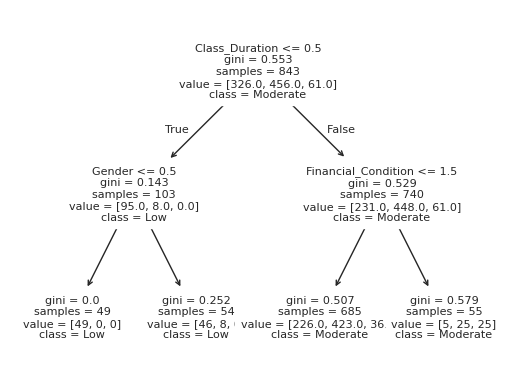

In [49]:
# Using the plot tree function to visualize the decision tree created by the DecisionTreeClassifier.

tree.plot_tree(clf, feature_names=fn, class_names = cn, fontsize=8)
plt.show()

In [50]:
# Decision tree with max depth = 2
dt2 = DecisionTreeClassifier(random_state = 0, max_depth=2)

# Train the decision tree on the training data
dt2.fit(x_train, y_train)

# Evaluate the performance on the training and testing set
dt2_score_train = dt2.score(x_train, y_train)
print("Training score: ",dt2_score_train)

dt2_score_test = dt2.score(x_test, y_test)
print("Testing score: ",dt2_score_test)

Training score:  0.6441281138790036
Testing score:  0.5966850828729282


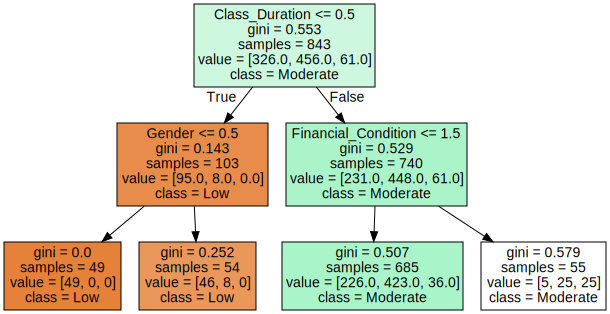

In [51]:
import graphviz

# DOT data
dot_data = tree.export_graphviz(dt2, out_file=None, feature_names=fn, class_names=cn, filled=True)

# Display the graph
graph = graphviz.Source(dot_data, format="png")
graph

In [52]:
# Create an DecisionTreeClassifier instance.
dt3 = DecisionTreeClassifier(random_state = 0, max_depth=3)

# Train the model.
dt3.fit(x_train, y_train)

# Evaluation on training and testing set.
dt3_score_train = dt3.score(x_train, y_train)
print("Training score: ",dt3_score_train)

dt3_score_test = dt3.score(x_test, y_test)
print("Testing score: ",dt3_score_test)

Training score:  0.6571767497034401
Testing score:  0.643646408839779


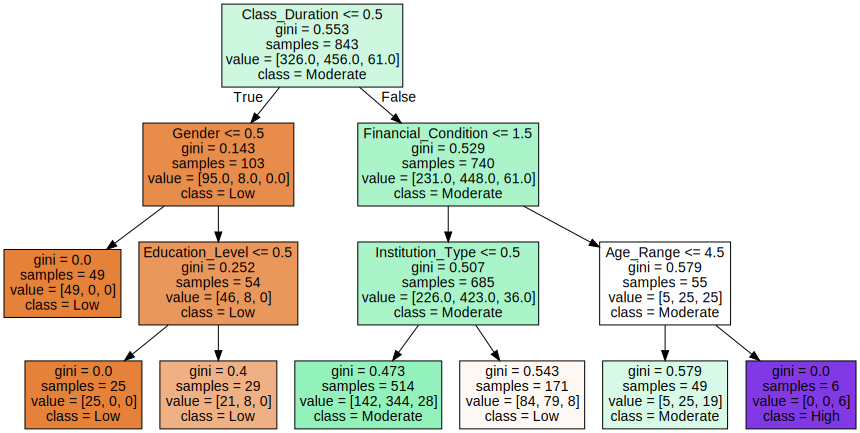

In [53]:
# DOT data
dot_data = tree.export_graphviz(dt3, out_file=None, feature_names=fn, class_names=cn, filled=True)

# Display the graph
graph = graphviz.Source(dot_data, format="png")
graph

In [54]:
# Create an DecisionTreeClassifier instance.
dt4 = DecisionTreeClassifier(random_state = 0, max_depth=4)

# Train the model.
dt4.fit(x_train, y_train)

# Evaluation on training and testing set.
dt4_score_train = dt4.score(x_train, y_train)
print("Training score: ",dt3_score_train)

dt4_score_test = dt4.score(x_test, y_test)
print("Testing score: ",dt3_score_test)

Training score:  0.6571767497034401
Testing score:  0.643646408839779


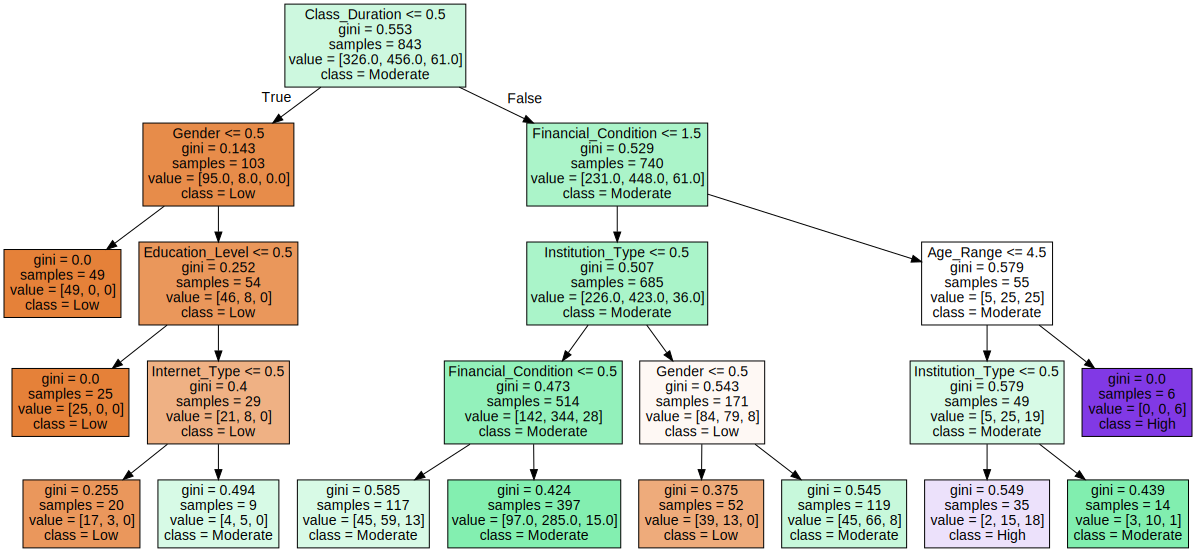

In [55]:
# DOT data
dot_data = tree.export_graphviz(dt4, out_file=None, feature_names=fn, class_names=cn, filled=True)

# Display the graph
graph = graphviz.Source(dot_data, format="png")
graph

In [56]:
# Displaying Decision Tree Scores in a table.
print('{:10} {:20} {:20}'.format('depth', 'Training score','Testing score'))
print('{:10} {:20} {:20}'.format('-----', '--------------','-------------'))

# Rows of the table with scores for different depths.
print('{:1} {:>25} {:>22}'.format(2, dt2_score_train, dt2_score_test))
print('{:1} {:>25} {:>22}'.format(3, dt3_score_train, dt3_score_test))
print('{:1} {:>25} {:>22}'.format(4, dt4_score_train, dt4_score_test))

depth      Training score       Testing score       
-----      --------------       -------------       
2        0.6441281138790036     0.5966850828729282
3        0.6571767497034401      0.643646408839779
4        0.6868327402135231     0.6712707182320442


In [57]:
# Displaying feature importances in a Decision Tree with max depth = 2.
features = x_train.columns.tolist()

# Features in the training set
dt2 = tree.DecisionTreeClassifier(random_state=0, max_depth=2)
dt2.fit(x_train, y_train)

# Create a DecisionTreeClassifier with a maximum depth of 2.
fi = dt2.feature_importances_

# Get feature importances from the trained decision tree.
l = len(features)
for i in range(0,len(features)):

    print('{:.<20} {:3}'.format(features[i],fi[i]))

Gender.............. 0.01543182082460347
Age_Range........... 0.0
Education_Level..... 0.0
Institution_Type.... 0.0
IT_Student.......... 0.0
Location............ 0.0
Load_shedding....... 0.0
Financial_Condition. 0.17089793331760073
Internet_Type....... 0.0
Network_Type........ 0.0
Class_Duration...... 0.8136702458577958
Self_Lms............ 0.0
Device.............. 0.0


In [58]:
# Displaying feature importances in a Decision Tree with max depth = 3.
features = x_train.columns.tolist()

# Features in the training set
dt3 = tree.DecisionTreeClassifier(random_state=0, max_depth=3)
dt3.fit(x_train, y_train)

# Create a DecisionTreeClassifier with a maximum depth of 3.
fi = dt3.feature_importances_

# Get feature importances from the trained decision tree.
l = len(features)
for i in range(0,len(features)):

    print('{:.<20} {:3}'.format(features[i],fi[i]))

Gender.............. 0.012527131235349893
Age_Range........... 0.03833546548777328
Education_Level..... 0.022700466524297
Institution_Type.... 0.12719134345127203
IT_Student.......... 0.0
Location............ 0.0
Load_shedding....... 0.0
Financial_Condition. 0.1387302809469128
Internet_Type....... 0.0
Network_Type........ 0.0
Class_Duration...... 0.6605153123543951
Self_Lms............ 0.0
Device.............. 0.0


In [59]:
# Displaying feature importances in a Decision Tree with max depth = 4.
features = x_train.columns.tolist()

# Features in the training set.
dt4 = tree.DecisionTreeClassifier(random_state=0, max_depth=4)
dt4.fit(x_train, y_train)

# Create a DecisionTreeClassifier with a maximum depth of 4.
fi = dt4.feature_importances_

# Get feature importances from the trained decision tree.
l = len(features)
for i in range(0,len(features)):

    print('{:.<20} {:3}'.format(features[i],fi[i]))

Gender.............. 0.08775611960968135
Age_Range........... 0.031372397109019845
Education_Level..... 0.018577263672131385
Institution_Type.... 0.13158531157525621
IT_Student.......... 0.0
Location............ 0.0
Load_shedding....... 0.0
Financial_Condition. 0.17160422997996339
Internet_Type....... 0.018562169645397766
Network_Type........ 0.0
Class_Duration...... 0.5405425084085499
Self_Lms............ 0.0
Device.............. 0.0


In [60]:
# Making Predictions and calculating Accuracy Score
predict = dt2.predict(x_test)

# Calculate the accuracy score
print("\nAccuracy score: \n{}".format(metrics.accuracy_score(y_test, predict)))


Accuracy score: 
0.5966850828729282


In [61]:
# Produce Classification Report

from sklearn.metrics import classification_report
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.96      0.32      0.48       154
           1       0.54      0.99      0.70       169
           2       0.00      0.00      0.00        39

    accuracy                           0.60       362
   macro avg       0.50      0.44      0.39       362
weighted avg       0.66      0.60      0.53       362



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


*   
*    
*  
*  
*    
*    







 **RANDOM FOREST MODEL**

In [62]:
# Specifying columns'Adaptivity_Level'
# These columns are chosen as potential features that the model will use to make predictions.

x = data.drop(['Adaptivity_Level'], axis=1)

# This variable represents the target variable that the machine learning model aims to predict.

y = data['Adaptivity_Level']

In [63]:
# Splitting by stratifying by cluster name for equal representation of data

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [64]:
# Make an instance of the Model.
rfc = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(rfc, x, y, cv=5)
print(cv_scores)

[0.95020747 0.91701245 0.89211618 0.89626556 0.8879668 ]


In [65]:
# Train the model on the data
rfc.fit(x_train, y_train)

# Get feature importances
feature_importances = rfc.feature_importances_

y_pred = rfc.predict(x_test)

In [66]:
# Evaluate accuracy score

accuracy_rf = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_rf)

Accuracy: 0.8879668049792531


In [67]:
# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       103
           1       0.88      0.90      0.89       115
           2       0.88      0.65      0.75        23

    accuracy                           0.89       241
   macro avg       0.89      0.83      0.85       241
weighted avg       0.89      0.89      0.89       241



In [68]:
# Create a DataFrame to display feature importances.
importances_df = pd.DataFrame({'Feature': x.columns, 'Importance': feature_importances})

# Sort features by importance in descending order.
importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Print feature importances.
print(importances_df)

                Feature  Importance
10       Class_Duration    0.175111
1             Age_Range    0.119286
7   Financial_Condition    0.115274
0                Gender    0.083868
2       Education_Level    0.067644
9          Network_Type    0.063492
5              Location    0.061396
8         Internet_Type    0.060011
3      Institution_Type    0.059241
11             Self_Lms    0.053399
4            IT_Student    0.048489
12               Device    0.047654
6         Load_shedding    0.045135


*   
*    
*  
*  
*    
*    







**GRADIENT BOOST MODEL**

In [69]:
# Specifying columns'Adaptivity_Level'
# These columns are chosen as potential features that the model will use to make predictions

x = data.drop(['Adaptivity_Level'], axis=1)

# This variable represents the target variable that the machine learning model aims to predict

y = data['Adaptivity_Level']

In [70]:
# Splitting by stratifying by cluster name for equal representation of data

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [71]:
# Initialize and train the Gradient Boosting Classifier model

gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42)
gbc.fit(x_train, y_train)

GradientBoostingClassifier(max_depth=2, random_state=42)

In [72]:
# Make predictions.

y_pred = gbc.predict(x_test)

In [73]:
# Calculate accuracy score

accuracy_gbc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy_gbc)

Test Accuracy: 0.7925311203319502


In [74]:
# Generate and print the classification report

report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.80       103
           1       0.74      0.89      0.81       115
           2       0.86      0.52      0.65        23

    accuracy                           0.79       241
   macro avg       0.82      0.72      0.75       241
weighted avg       0.80      0.79      0.79       241



*   
*    
*  
*  
*    
*    







**COMPARISON BETWEEN MODEL**

In [75]:
# Define the models and their corresponding accuracies.
models = [
    "Random Forest",
    "Gaussian Process",
    "Gradient Boost",
    "Logistic Regression",
    "Decision Tree"
]

accuracies = [
    accuracy_rf,
    test_accuracy_gp,
    accuracy_gbc,
    accuracy_lr,
    dt2_score_test
]

# Create a DataFrame
comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies,

})

# Display the DataFrame
print(comparison_df)

                 Model  Accuracy
0        Random Forest  0.887967
1     Gaussian Process  0.820442
2       Gradient Boost  0.792531
3  Logistic Regression  0.665746
4        Decision Tree  0.596685


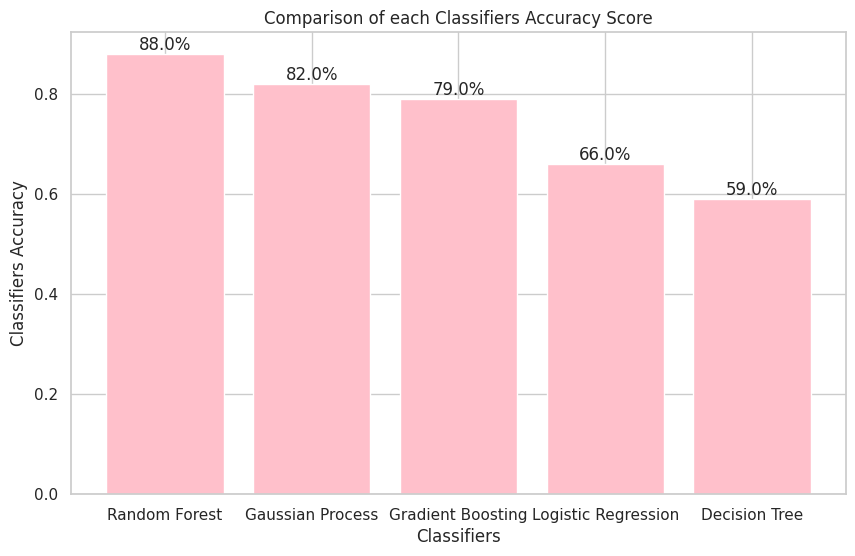

In [76]:
classifiers_name = ['Random Forest', 'Gaussian Process', 'Gradient Boosting', 'Logistic Regression', 'Decision Tree']
classifiers_accuracy = [0.88, 0.82, 0.79, 0.66, 0.59]

plt.figure(figsize=(10, 6))

bars = plt.bar(classifiers_name, np.round(classifiers_accuracy, 3), width=0.8, color='pink')

# Annotate each bar with its percentage
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.1%}', ha='center', va='bottom')

plt.xlabel('Classifiers')
plt.ylabel('Classifiers Accuracy')
plt.title('Comparison of each Classifiers Accuracy Score')

plt.show()

# **7. CONCLUSION**

Since Random Forest Model is the highest accuracy score that we got, we are going to use Random Forest to find the feature importance that affect students adaptability in online learning.

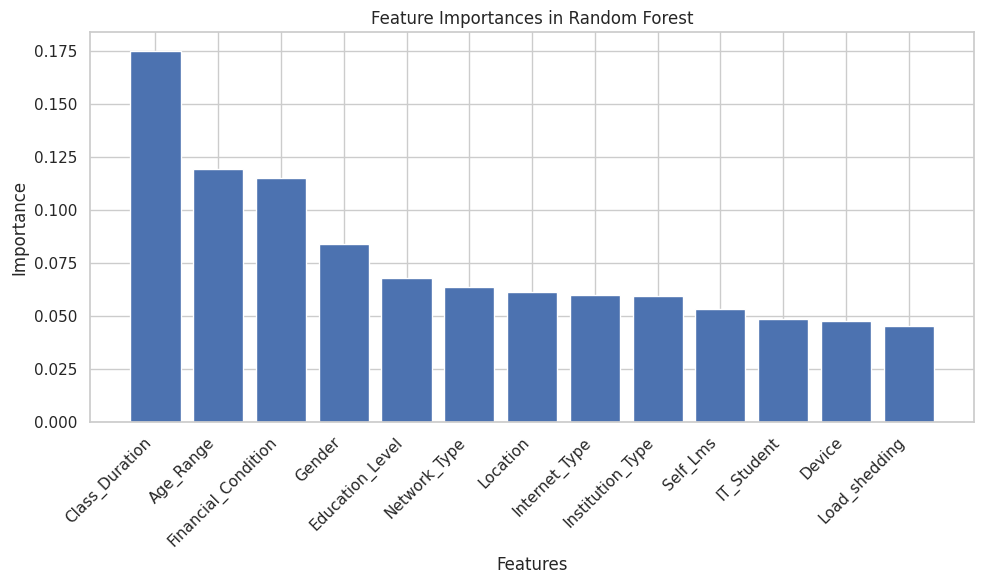

In [77]:
# Feature importances of Random Forest.
plt.figure(figsize=(10, 6))
plt.bar(importances_df['Feature'], importances_df['Importance'])

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importances in Random Forest')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

The results of this investigation may help decision-makers in the education sector have a clear understanding of the state of the online education field and student adaptation.

The key findings from the 3rd highest feature importances are;

*   Teaching staff should make sure that their courses last between one and three hours because of the effect that a longer class length has on adaptivity.
*   Even when teaching online, age-appropriate teaching strategies should be used.
*   Better internet access options are one way that government institutions may support their students, particularly those enrolled in government schools.







In [78]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
